[![](imagens/colab-badge.png){width="16%"}](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap07/cap07_aluno.ipynb)
[![](imagens/github-badge.png){width="19%"}](https://github.com/fzampirolli/pdi-vc)

# Classificação de Imagens e Reconhecimento de Padrões

🚧 **Em construção!**

No **Capítulo 6**, a transição da Parte I para a Parte II foi apresentada por meio de duas aplicações que já exigiam decisões automatizadas: o reconhecimento de marcas em folhas de resposta (OMR) e a detecção de defeitos em inspeção industrial. Em ambos os casos, no entanto, as decisões dependiam de regras geométricas e de limiares definidos manualmente, como determinar se um disco era suficientemente circular ou se uma região era escura o bastante.

Este capítulo formaliza o problema mais geral subjacente a essas aplicações: dado um conjunto de exemplos rotulados, como treinar um sistema para **classificar automaticamente** novas imagens ou regiões de interesse? Essa questão está no núcleo do **Reconhecimento de Padrões**, disciplina que fundamenta grande parte das tarefas modernas de Visão Computacional, desde a classificação de imagens até a detecção de objetos e a segmentação semântica, exploradas nos próximos capítulos.

Serão estudados os principais **descritores clássicos de imagem** (cor, textura e forma/gradiente) e o classificador **k-Vizinhos mais Próximos** (*k-Nearest Neighbors* — k-NN), escolhido por sua simplicidade conceitual e por evidenciar, de forma direta, a relação entre o espaço de características, as métricas de distância e as fronteiras de decisão — conceitos que permanecem centrais mesmo em classificadores baseados em redes neurais profundas, estudados no capítulo final desta parte.



## Objetivos do Capítulo

Ao final deste capítulo, o estudante deverá ser capaz de:

* Compreender o ***pipeline* clássico de reconhecimento de padrões**: aquisição, pré-processamento, extração de descritores, classificação e avaliação;
* **Extrair e interpretar descritores clássicos** de cor, textura (*Local Binary Patterns* — LBP) e forma/gradiente (*Histogram of Oriented Gradients* — HOG);
* **Implementar e treinar um classificador k-NN** para tarefas de classificação de imagens;
* **Avaliar classificadores** por meio de métricas como acurácia, matriz de confusão, precisão e revocação;
* **Analisar o efeito do parâmetro k** e da dimensionalidade do espaço de características no desempenho do classificador;
* **Reconhecer as limitações dos descritores artesanais** (*hand-crafted features*) e compreender a motivação para a transição, nos próximos capítulos, para descritores aprendidos automaticamente.

## Configuração do Ambiente

Os exemplos deste capítulo utilizam bibliotecas amplamente empregadas em
Processamento Digital de Imagens, Visão Computacional e Aprendizado de
Máquina. O bloco abaixo instala os pacotes necessários; em ambientes que já
os possuam, a execução pode ser ignorada.


In [1]:
#| quarto-raw: true

# Instalar apenas as bibliotecas ausentes
import importlib
import subprocess
import sys

for mod, pkg in {
    "cv2": "opencv-python",
    "skimage": "scikit-image",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "pandas": "pandas",
    "tabulate": "tabulate",
}.items():
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

# Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data as skdata
from skimage.feature import hog, local_binary_pattern


Assim como no capítulo anterior, será utilizado o módulo didático
`morph.py`, responsável por padronizar a leitura, a exibição e o
processamento de imagens ao longo do livro.


In [2]:
#| quarto-raw: true

import os
import urllib.request

if not os.path.exists("morph.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph/morph.py",
        "morph.py",
    )

import morph
from morph import mm

print(f"✅ Ambiente pronto. morph {getattr(morph, '__version__', 'local_file')}")


✅ Ambiente pronto. morph 1.1.2


## Um Problema Concreto: Classificação de Frutas

Antes de apresentar os fundamentos teóricos, considere o seguinte problema,
que será utilizado como exemplo ao longo deste capítulo para ilustrar os
principais conceitos de reconhecimento de padrões.

**O cenário:** Uma fazenda automatizada utiliza um sistema de Visão
Computacional para separar maçãs, bananas e laranjas em linhas de
embalagem.

**O desafio:** As frutas chegam à esteira em diferentes posições e
orientações, sob condições de iluminação que podem variar. Além disso,
folhas, sombras e pequenas oclusões podem dificultar sua identificação.
Como desenvolver um sistema capaz de classificá-las corretamente?

**Uma possível abordagem:**

1. Extrair descritores que representem características relevantes das
   frutas:
   - **Cor:** distribuição predominante das cores;
   - **Textura:** diferenças na superfície da casca;
   - **Forma:** características geométricas do contorno.

2. Treinar um classificador utilizando exemplos previamente rotulados.

3. Utilizar o modelo treinado para classificar automaticamente novas
   frutas.

A @fig-07-frutas-motivacao ilustra, de forma conceitual, como diferentes
frutas podem ser representadas em um espaço de características
tridimensional.

:::{.callout-tip}
## Reflita antes de continuar

Se cada fruta fosse representada apenas pelos valores de intensidade de
seus pixels, seria possível distingui-las de forma confiável? Que tipos de
informação poderiam ser extraídos da imagem para facilitar essa tarefa?
:::

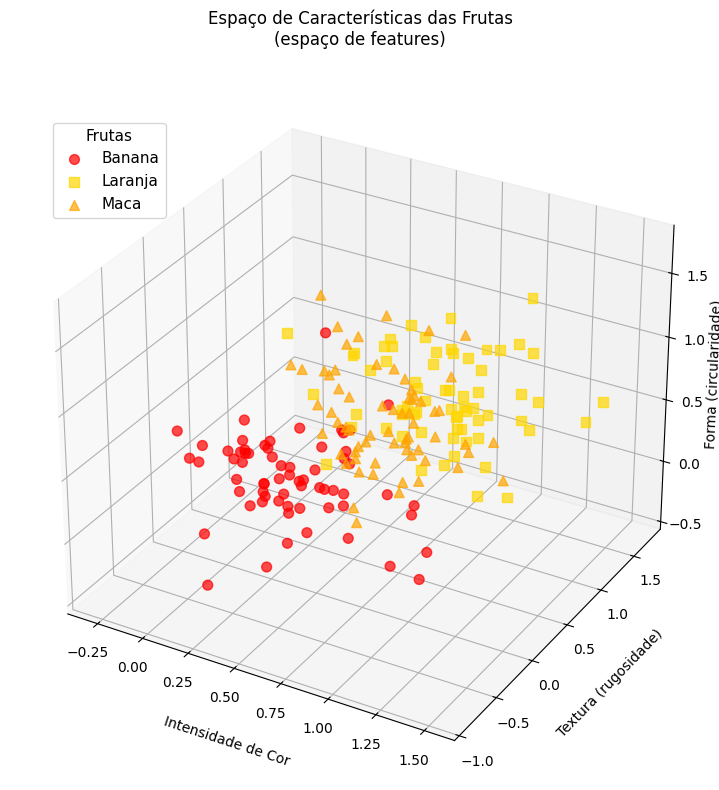


Observe como as frutas formam agrupamentos distintos!
   - Maçãs (vermelho): alta cor, forma redonda
   - Bananas (amarelo): baixa forma (alongadas)
   - Laranjas (laranja): alta textura (rugosas)


In [3]:
#| label: fig-07-frutas-motivacao
#| fig-cap: "Exemplo motivacional: diferentes frutas com variações de iluminação e rotação. Observe como cada fruta forma um agrupamento distinto no espaço de características."
#| echo: true
#| output: true

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Gerar dados sintéticos simulando descritores de frutas
def gerar_dados_frutas(n_amostras=200, ruido=0.3):
    """Gera dados sintéticos que simulam descritores de frutas"""
    np.random.seed(42)
    
    centros = {
        'Maca': [0.8, 0.2, 0.9],   # Vermelha, lisa, redonda
        'Banana': [0.3, 0.1, 0.2],  # Amarela, lisa, alongada
        'Laranja': [0.9, 0.8, 0.8]  # Laranja, rugosa, redonda
    }
    
    X = []
    y = []
    
    for fruta, centro in centros.items():
        dados = np.random.randn(n_amostras // 3, 3) * ruido + centro
        X.append(dados)
        y.extend([fruta] * (n_amostras // 3))
    
    X = np.vstack(X)
    return X, y

# Gerar dados
X, y = gerar_dados_frutas()

# Configuração da figura com margens ampliadas nas bordas
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Separar por classe e plotar
frutas_unicas = np.unique(y)
cores_plot = ['red', 'gold', 'orange']
marcadores = ['o', 's', '^']

for i, fruta in enumerate(frutas_unicas):
    mask = np.array(y) == fruta
    ax.scatter(X[mask, 0], X[mask, 1], X[mask, 2], 
              c=cores_plot[i], label=fruta, alpha=0.7, s=50,
              marker=marcadores[i])

# Ajuste fino das legendas dos eixos e espaçamentos
ax.set_xlabel('Intensidade de Cor', labelpad=12)
ax.set_ylabel('Textura (rugosidade)', labelpad=12)
ax.set_zlabel('Forma (circularidade)', labelpad=0)
ax.set_title('Espaço de Características das Frutas\n(espaço de features)', pad=25)
ax.legend(loc='upper left', bbox_to_anchor=(0.05, 0.95), title='Frutas', title_fontsize='11', fontsize='11')

# Ajustes para evitar corte do eixo
ax.set_box_aspect((1, 1, 0.8))
ax.dist = 12

plt.subplots_adjust(left=0.15, right=0.9, bottom=0.15, top=0.85)
plt.show()

print("\nObserve como as frutas formam agrupamentos distintos!")
print("   - Maçãs (vermelho): alta cor, forma redonda")
print("   - Bananas (amarelo): baixa forma (alongadas)")
print("   - Laranjas (laranja): alta textura (rugosas)")

## Fundamentos de Reconhecimento de Padrões

Um sistema de **reconhecimento de padrões** tem como objetivo atribuir uma
categoria (rótulo) a uma observação — uma imagem inteira, uma região de
interesse ou um sinal — com base em exemplos previamente rotulados. De
forma geral, esse processo é organizado nas seguintes etapas:

1. **Aquisição:** obtenção da imagem ou do sinal a ser classificado;
2. **Pré-processamento:** normalização, remoção de ruído, correção
   geométrica ou de iluminação — etapas já estudadas nos capítulos
   anteriores;
3. **Extração de descritores (*features*):** transformação da imagem em
   um **vetor de características** de dimensão fixa, que representa as
   propriedades relevantes para a tarefa de classificação;
4. **Classificação:** aplicação de um modelo que associa o vetor de
   características a uma classe;
5. **Avaliação:** análise do desempenho do modelo em um conjunto de dados
   independente daquele utilizado para o treinamento.

O conjunto de todos os vetores de características possíveis constitui o
**espaço de características** (*feature space*). Um bom descritor produz
representações que aproximam, nesse espaço, observações da mesma classe e
afastam observações de classes distintas. Essa propriedade favorece
métodos de classificação baseados em proximidade, como o **k-NN**, e
também beneficia diversos outros classificadores.

A @fig-07-frutas-motivacao ilustra esse conceito de forma esquemática:
cada fruta é representada por um ponto em um espaço de características de
três dimensões (cor, textura e forma). Embora esse espaço seja apenas uma
simplificação didática, ele mostra como amostras da mesma classe tendem a
formar agrupamentos, enquanto classes diferentes ocupam regiões distintas,
facilitando a tarefa de classificação.

## Extração de Descritores Clássicos

Antes da popularização das redes neurais profundas, os descritores de
imagem eram, em sua maioria, projetados manualmente por especialistas
(*hand-crafted features*), com base em propriedades estatísticas ou
geométricas conhecidas. Três famílias clássicas são particularmente
relevantes:

* **Descritores de cor:** histogramas de intensidade ou de matiz,
  que capturam a distribuição dos valores de cor de uma região, já
  introduzidos no **Capítulo 3** por meio da função `mm.hist`;
* **Descritores de textura:** capturam padrões locais de repetição,
  rugosidade ou orientação, como o *Local Binary Patterns* (LBP),
  estudado a seguir;
* **Descritores de forma/gradiente:** descrevem a distribuição das
  bordas e das orientações do gradiente, como o *Histogram of Oriented
  Gradients* (HOG), amplamente empregado na detecção de pessoas e
  outros objetos.

Para entender por que descritores são tão poderosos, a @fig-07-visualizacao-descritores
mostra como diferentes técnicas "enxergam" a mesma imagem.

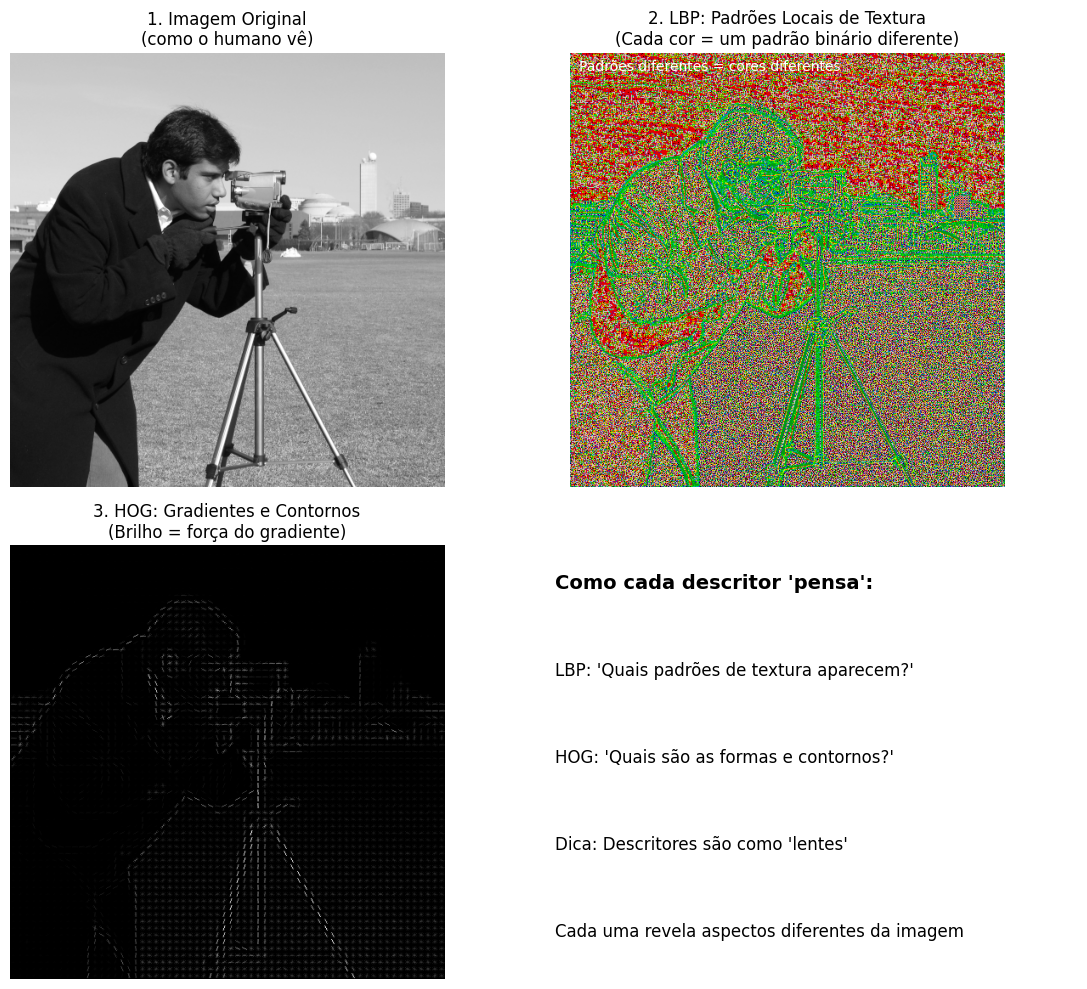


Observe como cada descritor destaca propriedades diferentes:
   - LBP: captura padrões de textura (ex: áreas rugosas vs lisas)
   - HOG: captura contornos e formas (ex: bordas do objeto)
   - Pixels brutos: apenas intensidade (mais suscetível a variações)


In [4]:
#| label: fig-07-visualizacao-descritores
#| fig-cap: "Comparação visual de diferentes descritores aplicados à mesma imagem. Cada descritor revela aspectos distintos da cena."
#| echo: true
#| output: true

import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern, hog
from skimage import data

# Carregar uma imagem exemplo
imagem = data.camera()

# Calcular descritores
def calcular_lbp_visual(img, P=8, R=1):
    """Calcula LBP e retorna imagem codificada"""
    lbp = local_binary_pattern(img, P=P, R=R, method='uniform')
    return lbp

def calcular_hog_visual(img):
    """Calcula HOG e retorna os gradientes"""
    features, hog_image = hog(img, orientations=9, pixels_per_cell=(8, 8),
                            cells_per_block=(2, 2), visualize=True)
    return features, hog_image

# Aplicar descritores
lbp_img = calcular_lbp_visual(imagem)
_, hog_img = calcular_hog_visual(imagem)

# Visualização
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Imagem original
axes[0, 0].imshow(imagem, cmap='gray')
axes[0, 0].set_title('1. Imagem Original\n(como o humano vê)')
axes[0, 0].axis('off')

# LBP visualizado - CORREÇÃO DA LEGENDA
axes[0, 1].imshow(lbp_img, cmap='nipy_spectral')
axes[0, 1].set_title('2. LBP: Padrões Locais de Textura\n(Cada cor = um padrão binário diferente)')
axes[0, 1].axis('off')
axes[0, 1].text(10, 20, 'Padrões diferentes = cores diferentes', color='white', fontsize=10)

# HOG visualizado
axes[1, 0].imshow(hog_img, cmap='gray')
axes[1, 0].set_title('3. HOG: Gradientes e Contornos\n(Brilho = força do gradiente)')
axes[1, 0].axis('off')

# Explicação comparativa
axes[1, 1].axis('off')
axes[1, 1].text(0.1, 0.9, "Como cada descritor 'pensa':", 
                fontsize=14, fontweight='bold', transform=axes[1, 1].transAxes)
axes[1, 1].text(0.1, 0.7, "LBP: 'Quais padrões de textura aparecem?'", 
                fontsize=12, transform=axes[1, 1].transAxes)
axes[1, 1].text(0.1, 0.5, "HOG: 'Quais são as formas e contornos?'", 
                fontsize=12, transform=axes[1, 1].transAxes)
axes[1, 1].text(0.1, 0.3, "Dica: Descritores são como 'lentes'", 
                fontsize=12, transform=axes[1, 1].transAxes)
axes[1, 1].text(0.1, 0.1, "Cada uma revela aspectos diferentes da imagem", 
                fontsize=12, transform=axes[1, 1].transAxes)

plt.tight_layout()
plt.show()

print("\nObserve como cada descritor destaca propriedades diferentes:")
print("   - LBP: captura padrões de textura (ex: áreas rugosas vs lisas)")
print("   - HOG: captura contornos e formas (ex: bordas do objeto)")
print("   - Pixels brutos: apenas intensidade (mais suscetível a variações)")

### *Local Binary Patterns* (LBP)

O LBP é um descritor de textura que codifica, para cada pixel central
$g_c$, a relação entre sua intensidade e a dos $P$ vizinhos dispostos em
uma vizinhança circular de raio $R$:

$$
\mathrm{LBP}_{P,R}(x_c, y_c) = \sum_{p=0}^{P-1} s(g_p - g_c)\, 2^p,
\qquad
s(z) =
\begin{cases}
1, & z \geq 0 \\
0, & z < 0
\end{cases}
$$

em que:

- $(x_c, y_c)$ são as coordenadas do pixel central;
- $g_c$ é a intensidade do pixel central;
- $g_p$ é a intensidade do $p$-ésimo pixel vizinho;
- $P$ é o número de vizinhos considerados;
- $R$ é o raio da vizinhança circular;
- $p$ é o índice do vizinho, com $p = 0, 1, \ldots, P-1$;
- $s(z)$ é a função limiar definida na equação, em que $z = g_p - g_c$;
  ela assume valor 1 quando $z \geq 0$ e 0 quando $z < 0$;
- $2^p$ corresponde ao peso binário associado ao $p$-ésimo vizinho.

O código LBP obtido descreve o padrão local de contraste ao redor do
pixel central. O histograma dos códigos LBP calculados em uma região
constitui um vetor de características compacto para representar sua
textura. Na variante *uniforme* adotada neste capítulo, essa
representação apresenta invariância a transformações monotônicas da
intensidade, como variações graduais de iluminação.

A @fig-07-visualizacao-descritores ilustra o processo de codificação dos
padrões locais de textura pelo descritor LBP.

O **Projeto Prático 2** (seção
[Classificação de Texturas com Descritores LBP](#classificacao-de-texturas-com-descritores-lbp))
emprega o LBP na classificação de diferentes tipos de textura sintética.

### *Histogram of Oriented Gradients* (HOG)

O HOG é um descritor que representa a forma de um objeto por meio da
distribuição das orientações do gradiente local. Assim como no operador
de Canny (**Capítulo 6**), calcula-se inicialmente o gradiente:

$$
|\nabla f(x,y)| =
\sqrt{\left(\frac{\partial f}{\partial x}\right)^2 +
      \left(\frac{\partial f}{\partial y}\right)^2},
\qquad
\theta(x,y) =
\operatorname{atan2}\!\left(
\frac{\partial f}{\partial y},
\frac{\partial f}{\partial x}
\right).
$$

em que:

- $f(x,y)$ é a intensidade da imagem no pixel $(x,y)$;
- $\frac{\partial f}{\partial x}$ e $\frac{\partial f}{\partial y}$ são,
  respectivamente, as derivadas parciais da imagem nas direções
  horizontal e vertical;
- $|\nabla f(x,y)|$ é a magnitude do vetor gradiente no pixel $(x,y)$,
  indicando a intensidade da variação local da imagem;
- $\theta(x,y)$ é a orientação do vetor gradiente no pixel $(x,y)$,
  calculada pela função $\operatorname{atan2}$, cujo resultado pertence ao
  intervalo $(-\pi,\pi]$.

A imagem é então dividida em pequenas células. Para cada célula,
constrói-se um histograma das orientações do gradiente, ponderado pela
magnitude correspondente. A concatenação dos histogramas de todas as
células forma o vetor de características HOG, que representa a
distribuição espacial das orientações do gradiente e captura informações
sobre a forma e os contornos do objeto.

A @fig-07-visualizacao-descritores ilustra a representação produzida pelo
descritor HOG a partir da imagem original.

O **Projeto Prático 1** (seção
[Classificação de Dígitos Manuscritos com k-NN](#classificacao-de-digitos-manuscritos-com-k-nn))
compara o desempenho de descritores HOG com o uso direto das intensidades
dos pixels como vetor de características.

### O Impacto da Escala e a Normalização de Características

Como o classificador $k$-NN baseia-se diretamente em cálculos de distâncias geométricas (como a Euclidiana), ele é extremamente sensível à escala de magnitude das variáveis do vetor de características. Se uma característica possuir uma ordem de grandeza significativamente maior do que as outras (por exemplo, a intensidade de cor variando de $0$ a $255$ contra um índice de circularidade que varia de $0$ a $1$), essa variável dominará a soma dos quadrados das diferenças, anulando a influência dos demais atributos.

Para contornar essa distorção, aplica-se a **Normalização de Características** (geralmente por meio do *Z-score standardization*), garantindo que todas as dimensões do espaço de características contribuam equitativamente para a tomada de decisão. A **@fig-07-normalizacao-features** ilustra o efeito prático dessa etapa: sem a normalização, a distribuição dos dados é severamente distorcida ao longo do eixo de maior magnitude; após o escalonamento, os eixos tornam-se balanceados, permitindo que o cálculo de proximidade reflita a verdadeira vizinhança estrutural dos padrões.


📏 Efeito da Normalização:
   Feature 1: escala ~100 (domina as distâncias)
   Feature 2: escala ~1 (pouco influente)

   Sem normalização: a feature de maior escala domina completamente
   Com normalização: ambas as features têm o mesmo peso


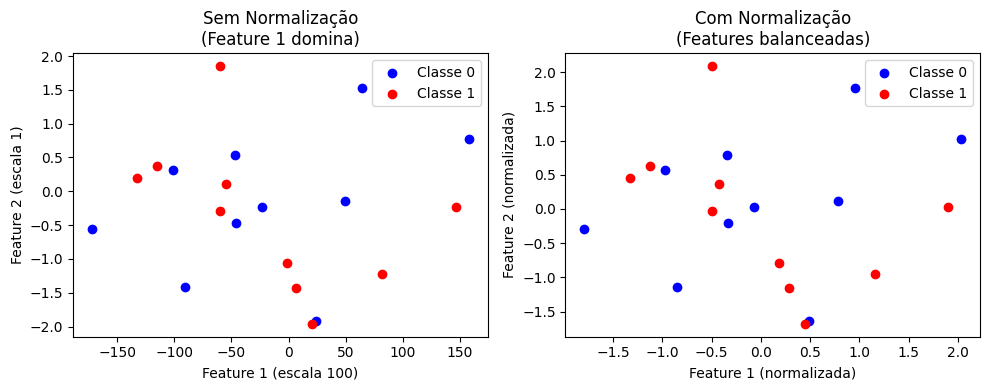


💡 A normalização é crucial quando features têm unidades diferentes!


In [5]:
#| label: fig-07-normalizacao-features
#| fig-cap: "Importância da normalização de features para o classificador k-NN"
#| echo: true
#| output: true

from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Demonstrar efeito da normalização
np.random.seed(42)
X_demo = np.random.randn(20, 2) * [100, 1]  # Features com escalas diferentes
y_demo = np.array([0]*10 + [1]*10)

# Sem normalização - distâncias dominadas pela primeira feature
print("📏 Efeito da Normalização:")
print(f"   Feature 1: escala ~100 (domina as distâncias)")
print(f"   Feature 2: escala ~1 (pouco influente)")
print("\n   Sem normalização: a feature de maior escala domina completamente")
print("   Com normalização: ambas as features têm o mesmo peso")

# Exemplo visual
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Sem normalização
axes[0].scatter(X_demo[y_demo==0, 0], X_demo[y_demo==0, 1], c='blue', label='Classe 0')
axes[0].scatter(X_demo[y_demo==1, 0], X_demo[y_demo==1, 1], c='red', label='Classe 1')
axes[0].set_title('Sem Normalização\n(Feature 1 domina)')
axes[0].set_xlabel('Feature 1 (escala 100)')
axes[0].set_ylabel('Feature 2 (escala 1)')
axes[0].legend()

# Com normalização
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_demo)
axes[1].scatter(X_norm[y_demo==0, 0], X_norm[y_demo==0, 1], c='blue', label='Classe 0')
axes[1].scatter(X_norm[y_demo==1, 0], X_norm[y_demo==1, 1], c='red', label='Classe 1')
axes[1].set_title('Com Normalização\n(Features balanceadas)')
axes[1].set_xlabel('Feature 1 (normalizada)')
axes[1].set_ylabel('Feature 2 (normalizada)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n💡 A normalização é crucial quando features têm unidades diferentes!")


## Descritores na Prática

Após a apresentação dos principais descritores clássicos, surge uma
questão importante: como eles se comportam diante de condições de
aquisição sujeitas a variações de iluminação e à presença de ruído?

Para responder a essa questão, a @fig-07-matrizes-confusao apresenta as
matrizes de confusão obtidas com cada abordagem, permitindo identificar
as classes em que ocorrem os principais erros de classificação. Em
complemento, a @fig-07-comparacao-descritores-detalhada resume a acurácia
obtida pelos descritores de pixels brutos, LBP e HOG em um cenário com
variações de iluminação e ruído estruturado.

Os resultados mostram que o desempenho do classificador depende da
representação utilizada para descrever as imagens. Enquanto o uso direto
das intensidades dos pixels é mais sensível às degradações introduzidas,
os descritores LBP e HOG preservam melhor as informações relevantes para
a classificação, resultando em maior desempenho nesse cenário.

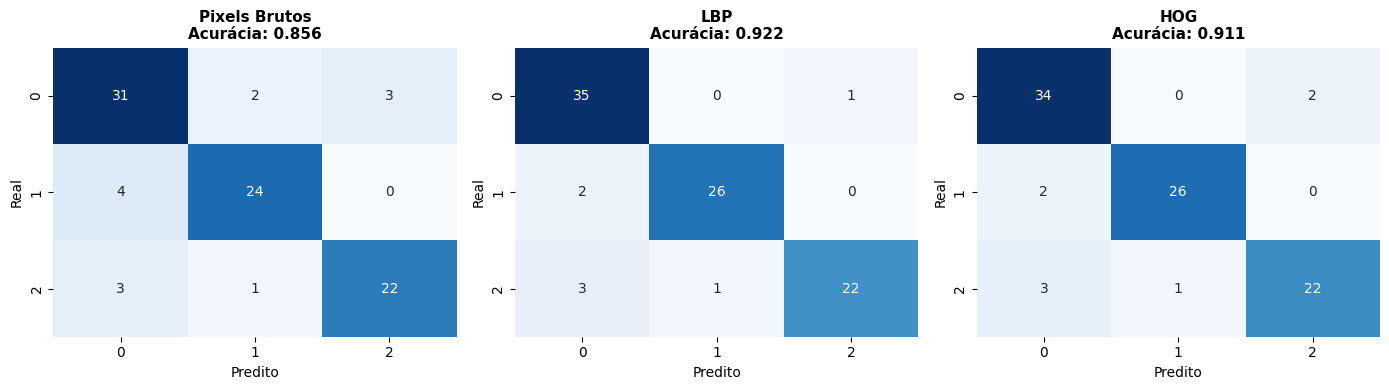

In [6]:
#| label: fig-07-matrizes-confusao
#| fig-cap: "Matrizes de confusão obtidas pelo classificador k-NN para cada tipo de descritor. Note o comportamento dos erros em dados com ruído estruturado."
#| echo: true
#| output: true

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.datasets import make_classification
import seaborn as sns

# Simular um dataset mais realista com variações
def gerar_dados_frutas_realistas():
    """Gera dados simulando frutas com diferentes condições"""
    np.random.seed(42)
    
    n_total = 300
    n_classes = 3
    n_features = 10
    
    # Gerar dados com características realistas
    X, y = make_classification(n_samples=n_total, n_features=n_features,
                              n_classes=n_classes, n_clusters_per_class=1,
                              n_informative=7, random_state=42)
    
    # Simular diferentes descritores para a mesma imagem
    descritores = {
        'Pixels Brutos': X + np.random.randn(*X.shape) * 0.5,
        'LBP': X + np.random.randn(*X.shape) * 0.3,
        'HOG': X + np.random.randn(*X.shape) * 0.2
    }
    
    return descritores, y

# Gerar dados
descritores, y = gerar_dados_frutas_realistas()

# Criar uma única figura com 3 subplots lado a lado para as matrizes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
resultados = {}

for idx, (nome, X) in enumerate(descritores.items()):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    resultados[nome] = acc
    
    # Matriz de confusão no subplot correspondente
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{nome}\nAcurácia: {acc:.3f}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Real')
    axes[idx].set_xlabel('Predito')

plt.tight_layout()
plt.show()

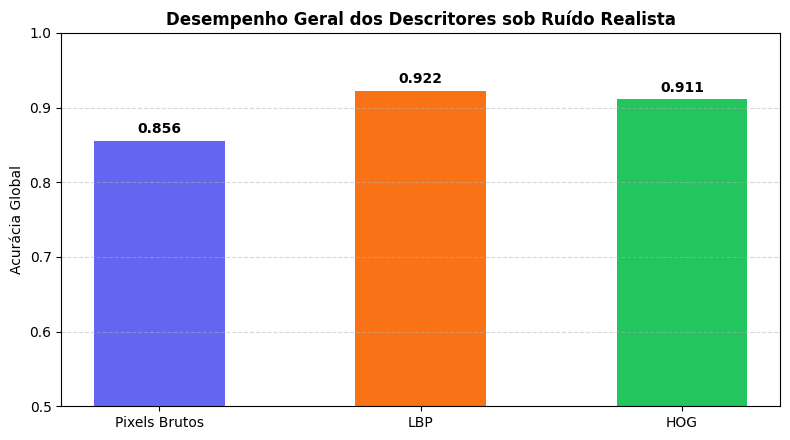


Análise dos resultados:
   - Pixels Brutos: Sensíveis a variações locais de iluminação e ruído.
   - LBP: Boa tolerância para variações monotônicas de iluminação global.
   - HOG: Excelente para contornos e formas estáveis sob pequenas flutuações geométricas.


In [7]:
#| label: fig-07-comparacao-descritores-detalhada
#| fig-cap: "Comparação detalhada de acurácia global em cenário realista. Observe como os descritores extraídos estruturalmente (LBP e HOG) superam o uso de intensidades puras de pixels brutos."
#| echo: true
#| output: true

# Comparação visual em uma figura isolada
plt.figure(figsize=(8, 4.5))
nomes = list(resultados.keys())
acuracia = list(resultados.values())
colors = ['#6366f1', '#f97316', '#22c55e']

bars = plt.bar(nomes, acuracia, color=colors, width=0.5)
plt.ylabel('Acurácia Global')
plt.title('Desempenho Geral dos Descritores sob Ruído Realista', fontsize=12, fontweight='bold')
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adicionar os valores acima das barras usando round padrão para exibição
for bar, val in zip(bars, acuracia):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\nAnálise dos resultados:")
print("   - Pixels Brutos: Sensíveis a variações locais de iluminação e ruído.")
print("   - LBP: Boa tolerância para variações monotônicas de iluminação global.")
print("   - HOG: Excelente para contornos e formas estáveis sob pequenas flutuações geométricas.")

## Classificador k-NN: Como Funciona por Dentro

O classificador k-NN não constrói um modelo explícito durante o
treinamento — ele armazena o conjunto de treinamento e, para cada nova
observação $x$, calcula sua distância a todos os exemplos conhecidos.

### Métrica de Distância

A métrica mais comum é a distância euclidiana entre vetores de
características:

$$
d(x, x_i) = \lVert x - x_i \rVert_2 =
\sqrt{\sum_{j=1}^{n} (x_j - x_{i,j})^2}.
$$

Outras métricas, como a distância de Manhattan ($\ell_1$) ou a distância
de Mahalanobis, também podem ser empregadas, dependendo da escala e da
correlação entre as dimensões do espaço de características.

### Regra de Decisão

Seja $N_k(x)$ o conjunto dos $k$ exemplos de treinamento mais próximos de
$x$ segundo a métrica escolhida. A classe predita $\hat y$ é a moda das
classes presentes em $N_k(x)$:

$$
\hat y = \operatorname{moda}\{\, y_i : x_i \in N_k(x) \,\}.
$$

Para entender na prática como cada etapa funciona, a @fig-07-knn-passo-passo
mostra a classificação passo-a-passo de um ponto de teste.

PASSO 1: Calculei a distância para cada ponto de treino
   Distâncias calculadas: 30

PASSO 2: Ordenei por distância (5 mais próximos):
   #1: distância=0.598, classe=0
   #2: distância=0.964, classe=0
   #3: distância=1.464, classe=0
   #4: distância=1.506, classe=0
   #5: distância=1.569, classe=0

PASSO 3: Selecionei os 3 vizinhos mais próximos

PASSO 4: Votação entre os vizinhos:
   Classe 0: 3 voto(s)

PASSO 5: Classe predita: 0 (maioria dos votos)


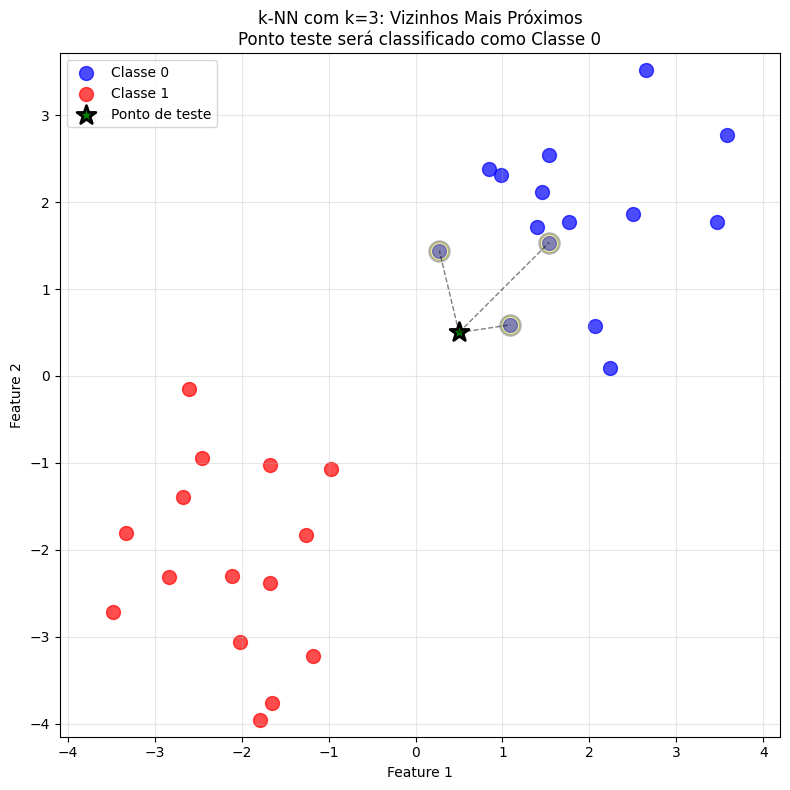


Resultado final: Ponto teste pertence à Classe 0


In [8]:
#| label: fig-07-knn-passo-passo
#| fig-cap: "Visualização passo-a-passo da classificação k-NN, mostrando como os vizinhos mais próximos são identificados e como a votação decide a classe final."
#| echo: true
#| output: true

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance

def knn_passo_a_passo(X_treino, y_treino, x_teste, k=3, mostrar_passos=True):
    """
    Implementação didática do k-NN mostrando cada etapa
    
    Parâmetros:
    - X_treino: dados de treino
    - y_treino: labels de treino  
    - x_teste: uma amostra para classificar
    - k: número de vizinhos
    - mostrar_passos: se True, mostra visualizações intermediárias
    """
    
    # PASSO 1: Calcular distâncias para todos os pontos de treino
    distancias = []
    for i, x_treino in enumerate(X_treino):
        dist = np.linalg.norm(x_teste - x_treino)
        distancias.append((dist, y_treino[i], i))
    
    print("PASSO 1: Calculei a distância para cada ponto de treino")
    print(f"   Distâncias calculadas: {len(distancias)}")
    
    # PASSO 2: Ordenar por distância
    distancias.sort(key=lambda x: x[0])
    
    if mostrar_passos:
        print("\nPASSO 2: Ordenei por distância (5 mais próximos):")
        for i in range(min(5, len(distancias))):
            print(f"   #{i+1}: distância={distancias[i][0]:.3f}, classe={distancias[i][1]}")
    
    # PASSO 3: Selecionar os k mais próximos
    k_vizinhos = distancias[:k]
    print(f"\nPASSO 3: Selecionei os {k} vizinhos mais próximos")
    
    # PASSO 4: Votação
    votos = {}
    for dist, classe, idx in k_vizinhos:
        votos[classe] = votos.get(classe, 0) + 1
    
    print("\nPASSO 4: Votação entre os vizinhos:")
    for classe, qtd in votos.items():
        print(f"   Classe {classe}: {qtd} voto(s)")
    
    # PASSO 5: Decisão
    classe_predita = max(votos, key=votos.get)
    print(f"\nPASSO 5: Classe predita: {classe_predita} (maioria dos votos)")
    
    return classe_predita, distancias, k_vizinhos

# Exemplo prático
np.random.seed(42)

# Criar dados de exemplo (2D para visualização)
n_amostras = 30
X_treino = np.random.randn(n_amostras, 2)
X_treino[:15] += [2, 2]  # Classe 0
X_treino[15:] += [-2, -2]  # Classe 1
y_treino = np.array([0]*15 + [1]*15)

# Ponto de teste
x_teste = np.array([0.5, 0.5])

# Classificar
classe_pred, distancias, vizinhos = knn_passo_a_passo(X_treino, y_treino, x_teste, k=3)

# Visualização
plt.figure(figsize=(8, 8))

# Plotar pontos de treino
plt.scatter(X_treino[y_treino==0, 0], X_treino[y_treino==0, 1], 
           c='blue', label='Classe 0', s=100, alpha=0.7)
plt.scatter(X_treino[y_treino==1, 0], X_treino[y_treino==1, 1], 
           c='red', label='Classe 1', s=100, alpha=0.7)

# Plotar ponto de teste
plt.scatter(x_teste[0], x_teste[1], c='green', s=200, 
           marker='*', label='Ponto de teste', edgecolors='black', linewidths=2)

# Destacar os k vizinhos
for dist, classe, idx in vizinhos:
    plt.scatter(X_treino[idx, 0], X_treino[idx, 1], 
               c='yellow', s=200, alpha=0.3, edgecolors='black', linewidths=2)
    # Linha até o ponto de teste
    plt.plot([x_teste[0], X_treino[idx, 0]], 
            [x_teste[1], X_treino[idx, 1]], 'k--', alpha=0.5, linewidth=1)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'k-NN com k={3}: Vizinhos Mais Próximos\nPonto teste será classificado como Classe {classe_pred}')
plt.legend()
plt.grid(alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

print(f"\nResultado final: Ponto teste pertence à Classe {classe_pred}")

### O Papel do Parâmetro k

O parâmetro $k$ controla diretamente o compromisso entre viés e
variância (*bias-variance trade-off*):

* **k pequeno** (ex.: $k=1$): fronteira de decisão irregular, sensível a
  ruído e *outliers* — baixo viés, alta variância (tendência a
  *overfitting*);
* **k grande**: fronteira de decisão suave, que pode ignorar estruturas
  locais relevantes — alto viés, baixa variância (tendência a
  *underfitting*).

Em problemas de duas classes, recomenda-se utilizar valores ímpares de
$k$ para evitar empates na votação.

O simulador da @fig-07-knn-simulador permite explorar interativamente o
efeito do parâmetro $k$ sobre a fronteira de decisão.

Além disso, em espaços de características de alta dimensão, a noção de
"proximidade" torna-se menos discriminativa — fenômeno conhecido como
**maldição da dimensionalidade** (*curse of dimensionality*): à medida que
o número de dimensões cresce, as distâncias entre pontos tendem a se
tornar mais uniformes, reduzindo a capacidade do k-NN de distinguir
vizinhos genuinamente próximos de pontos distantes.

In [9]:
#| label: fig-07-knn-simulador
#| fig-cap: "Simulador interativo da fronteira de decisão do k-NN: adicione pontos de treinamento e ajuste o valor de k para observar o efeito sobre a região de decisão."
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="knn7_Root">
<style>
  #knn7_Root * { box-sizing: border-box; }
  #knn7_Root { font-family: sans-serif; padding: 10px; max-width: 760px; margin: 0 auto; color: #374151; }
  #knn7_Root canvas { display: block; border-radius: 6px; border: 1px solid #d1d5db; background: #fff; cursor: crosshair; }
  #knn7_Root button { font-size: 11px; padding: 6px 12px; border-radius: 4px; border: 1px solid #d1d5db; background: #fff; color: #374151; cursor: pointer; transition: background 0.15s; }
  #knn7_Root button:hover { background: #f3f4f6; }
  #knn7_Root button.knn7_active { background: #4f46e5; color: #fff; border-color: #4f46e5; }
  #knn7_Root input[type=range] { width: 100%; accent-color: #6366f1; }
  .knn7_panel { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 10px; margin-bottom: 8px; }
  .knn7_row { display: flex; align-items: center; gap: 10px; flex-wrap: wrap; }
  .knn7_stat { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 8px 14px; text-align: center; min-width: 90px; }
  .knn7_stat_label { font-size: 9px; color: #6b7280; text-transform: uppercase; letter-spacing: 0.05em; margin-bottom: 2px; }
  .knn7_stat_value { font-size: 18px; font-weight: bold; font-family: monospace; color: #4f46e5; }
  .knn7_pill { font-size: 10px; font-weight: bold; padding: 3px 8px; border-radius: 4px; border: 1px solid #a5b4fc; background: #eef2ff; color: #4338ca; }
  .knn7_legend { display: flex; align-items: center; gap: 6px; font-size: 11px; }
  .knn7_dot { width: 10px; height: 10px; border-radius: 50%; display: inline-block; border: 1px solid rgba(0,0,0,0.2); }
</style>

<div class="knn7_panel" style="display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-size:12px;font-weight:bold;color:#4b5563;">Simulador: Fronteira de Decisão do k-NN</span>
  <span class="knn7_pill">Clique no canvas para adicionar pontos</span>
</div>

<div class="knn7_panel">
  <div class="knn7_row" style="margin-bottom:8px;">
    <div class="knn7_stat"><div class="knn7_stat_label">k</div><div id="knn7_kVal" class="knn7_stat_value">3</div></div>
    <div class="knn7_stat"><div class="knn7_stat_label">Pontos Azuis</div><div id="knn7_nAzul" class="knn7_stat_value">0</div></div>
    <div class="knn7_stat"><div class="knn7_stat_label">Pontos Vermelhos</div><div id="knn7_nVerm" class="knn7_stat_value">0</div></div>
    <button id="knn7_btnAzul">Adicionar Azul</button>
    <button id="knn7_btnVerm">Adicionar Vermelho</button>
    <button id="knn7_btnLimpar">Limpar</button>
    <button id="knn7_btnReset">Resetar</button>
  </div>
  <label style="font-size:11px;font-weight:600;color:#374151;">Valor de k: <span id="knn7_slVal">3</span></label>
  <input type="range" id="knn7_slider" min="1" max="15" step="1" value="3">
</div>

<canvas id="knn7_canvas" width="640" height="360"></canvas>

<div class="knn7_panel" style="margin-top:10px;">
  <div class="knn7_row" style="justify-content:space-between;">
    <div class="knn7_legend"><span class="knn7_dot" style="background:#3b82f6;"></span> Classe Azul</div>
    <div class="knn7_legend"><span class="knn7_dot" style="background:#ef4444;"></span> Classe Vermelha</div>
    <div style="font-size:11px;color:#6b7280;">A região colorida de fundo mostra a classe que o k-NN atribuiria a cada ponto do plano.</div>
  </div>
</div>
</div>

<script>
(function(){
  const knn7_canvas = document.getElementById("knn7_canvas");
  const knn7_ctx = knn7_canvas.getContext("2d");
  const knn7_W = knn7_canvas.width, knn7_H = knn7_canvas.height;
  const knn7_CELL = 10;

  let knn7_currentLabel = 0; // 0 = azul, 1 = vermelho
  let knn7_k = 3;
  let knn7_points = [];

  function knn7_defaultPoints(){
    return [
      {x:120,y:260,l:0},{x:150,y:230,l:0},{x:100,y:200,l:0},{x:160,y:290,l:0},
      {x:90,y:250,l:0},{x:140,y:190,l:0},{x:175,y:250,l:0},{x:110,y:150,l:0},
      {x:200,y:230,l:0},{x:130,y:310,l:0},
      {x:480,y:100,l:1},{x:450,y:130,l:1},{x:500,y:160,l:1},{x:440,y:80,l:1},
      {x:510,y:110,l:1},{x:470,y:60,l:1},{x:430,y:150,l:1},{x:520,y:190,l:1},
      {x:490,y:220,l:1},{x:460,y:190,l:1},
      {x:300,y:170,l:0},{x:320,y:190,l:1},{x:280,y:200,l:1},{x:310,y:150,l:0}
    ];
  }

  function knn7_classify(x, y, k, pontos){
    if (pontos.length === 0) return null;
    const dists = pontos.map(p => ({
      d: (p.x-x)*(p.x-x) + (p.y-y)*(p.y-y),
      l: p.l
    }));
    dists.sort((a,b) => a.d - b.d);
    const vizinhos = dists.slice(0, Math.min(k, dists.length));
    let votos = [0, 0];
    vizinhos.forEach(v => votos[v.l]++);
    return votos[1] > votos[0] ? 1 : 0;
  }

  function knn7_render(){
    knn7_ctx.clearRect(0, 0, knn7_W, knn7_H);

    // Região de decisão (grade de baixa resolução)
    for (let gy = 0; gy < knn7_H; gy += knn7_CELL){
      for (let gx = 0; gx < knn7_W; gx += knn7_CELL){
        const cx = gx + knn7_CELL/2, cy = gy + knn7_CELL/2;
        const classe = knn7_points.length > 0 ? knn7_classify(cx, cy, knn7_k, knn7_points) : null;
        if (classe === 0) knn7_ctx.fillStyle = "rgba(59,130,246,0.15)";
        else if (classe === 1) knn7_ctx.fillStyle = "rgba(239,68,68,0.15)";
        else knn7_ctx.fillStyle = "#ffffff";
        knn7_ctx.fillRect(gx, gy, knn7_CELL, knn7_CELL);
      }
    }

    // Pontos de treinamento
    knn7_points.forEach(p => {
      knn7_ctx.beginPath();
      knn7_ctx.arc(p.x, p.y, 7, 0, 2*Math.PI);
      knn7_ctx.fillStyle = p.l === 0 ? "#2563eb" : "#dc2626";
      knn7_ctx.fill();
      knn7_ctx.lineWidth = 1.5;
      knn7_ctx.strokeStyle = "#ffffff";
      knn7_ctx.stroke();
    });

    document.getElementById("knn7_nAzul").textContent = knn7_points.filter(p => p.l === 0).length;
    document.getElementById("knn7_nVerm").textContent = knn7_points.filter(p => p.l === 1).length;
    document.getElementById("knn7_kVal").textContent = knn7_k;
  }

  knn7_canvas.addEventListener("click", function(ev){
    const rect = knn7_canvas.getBoundingClientRect();
    const scaleX = knn7_canvas.width / rect.width;
    const scaleY = knn7_canvas.height / rect.height;
    const x = (ev.clientX - rect.left) * scaleX;
    const y = (ev.clientY - rect.top) * scaleY;
    knn7_points.push({x:x, y:y, l:knn7_currentLabel});
    knn7_render();
  });

  document.getElementById("knn7_slider").addEventListener("input", function(ev){
    knn7_k = parseInt(ev.target.value, 10);
    document.getElementById("knn7_slVal").textContent = knn7_k;
    knn7_render();
  });

  const knn7_btnAzul = document.getElementById("knn7_btnAzul");
  const knn7_btnVerm = document.getElementById("knn7_btnVerm");

  function knn7_setLabel(l){
    knn7_currentLabel = l;
    knn7_btnAzul.classList.toggle("knn7_active", l === 0);
    knn7_btnVerm.classList.toggle("knn7_active", l === 1);
  }

  knn7_btnAzul.addEventListener("click", function(){ knn7_setLabel(0); });
  knn7_btnVerm.addEventListener("click", function(){ knn7_setLabel(1); });

  document.getElementById("knn7_btnLimpar").addEventListener("click", function(){
    knn7_points = [];
    knn7_render();
  });

  document.getElementById("knn7_btnReset").addEventListener("click", function(){
    knn7_points = knn7_defaultPoints();
    knn7_render();
  });

  knn7_setLabel(0);
  knn7_points = knn7_defaultPoints();
  knn7_render();
})();
</script>
""")

:::{.callout-note}
## O efeito do parâmetro k

Ao experimentar o simulador da @fig-07-knn-simulador, observa-se que valores baixos de $k$ (por
exemplo, $k=1$) produzem fronteiras irregulares, que se ajustam a cada
ponto individual — inclusive a possíveis exemplos ruidosos ou mal
rotulados. Ao aumentar $k$, a fronteira se torna progressivamente mais
suave, pois a decisão passa a refletir uma vizinhança maior, mais
resistente a ruído local, ao custo de poder ignorar pequenas estruturas
relevantes entre classes muito próximas ou desbalanceadas.

Na prática, o valor de $k$ não deve ser escolhido arbitrariamente, mas sim
por meio de **validação cruzada**, avaliando a acurácia média do modelo em
diferentes partições do conjunto de treinamento para vários valores de
$k$ — procedimento demonstrado na seção [Avaliação de Classificadores](#avaliacao-de-classificadores).
:::

## Projeto Prático 1: Classificação de Dígitos Manuscritos com k-NN

Este projeto utiliza a base pública `load_digits` do `scikit-learn`,
composta por 1797 imagens de dígitos manuscritos (0–9) em resolução
$8 \times 8$ pixels em escala de cinza. Cada imagem é representada por um
vetor de 64 atributos, correspondente às intensidades dos pixels. Essa
base é amplamente utilizada em exemplos didáticos de classificação por ser
pequena, aproximadamente balanceada entre as classes e não exigir
*download* externo.

A @fig-07-digits-amostra apresenta uma amostra das imagens da base de
dados.

Total de amostras: 1797, dimensão do vetor: 64
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


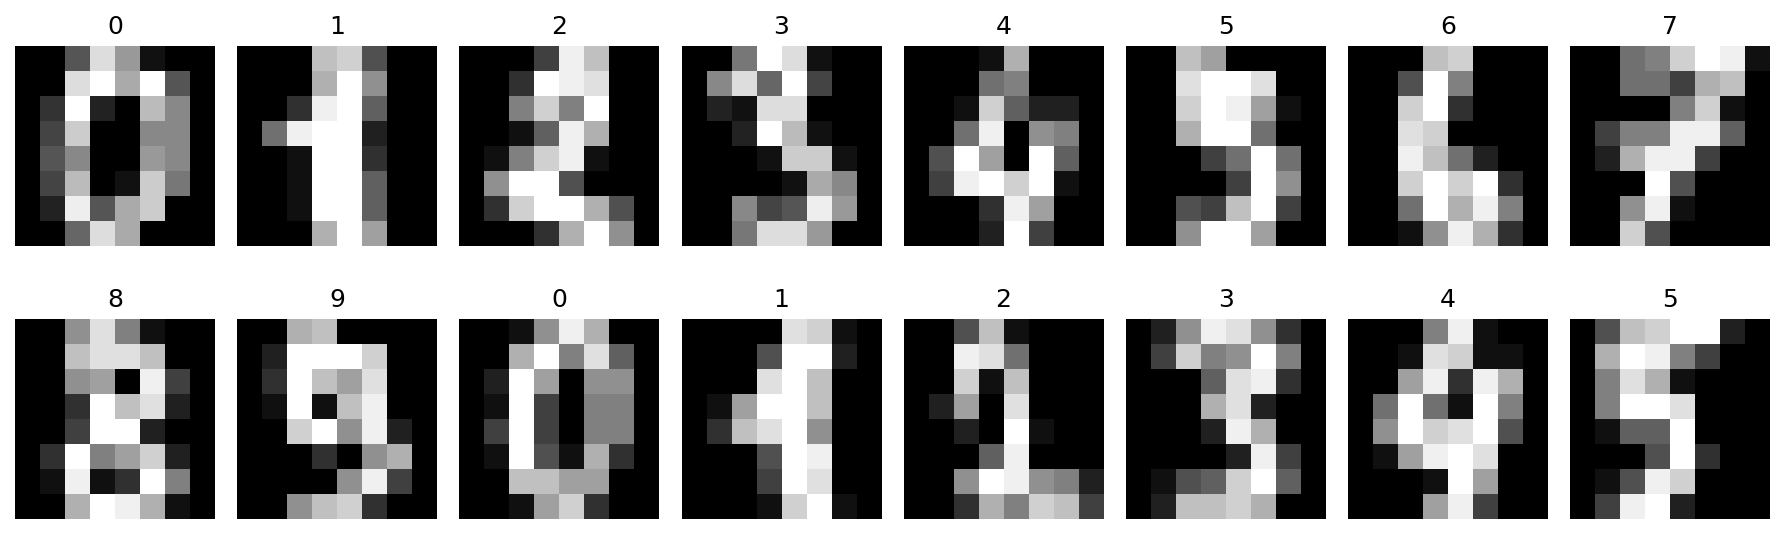

In [10]:
#| label: fig-07-digits-amostra
#| fig-cap: "Amostra de dígitos manuscritos da base *load_digits*, utilizada como estudo de caso de classificação."
#| echo: true
#| output: true

from sklearn.datasets import load_digits

digits = load_digits()
print(f"Total de amostras: {digits.data.shape[0]}, dimensão do vetor: {digits.data.shape[1]}")
print(f"Classes: {sorted(set(digits.target))}")

n_amostras = 16
imgs = list(digits.images[:n_amostras])
imgs_titles = [str(label) for label in digits.target[:n_amostras]]
mm.show(imgs, titles=imgs_titles, cols=8, figsize=(12, 4))


### Classificação com Vetores de Intensidade

Como primeira abordagem, cada imagem de dimensão $8 \times 8$ é
representada diretamente pelo vetor de intensidades de seus 64 pixels,
sem a extração de descritores adicionais. Esse vetor constitui o espaço de
características utilizado pelo classificador.

Em seguida, o conjunto de dados é dividido em subconjuntos de treinamento
e teste, preservando a proporção de exemplos de cada classe
(`stratify=y`). Um classificador k-NN com $k=3$ é então treinado com os
dados de treinamento e avaliado sobre o conjunto de teste por meio da
acurácia e da matriz de confusão, mostrada na @fig-07-knn-pixels.

Acurácia (vetores de intensidade, k=3): 0.9844


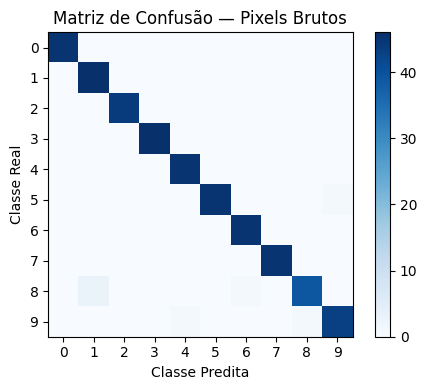

In [11]:
#| label: fig-07-knn-pixels
#| fig-cap: "Matriz de confusão do classificador k-NN treinado com vetores de intensidade brutos (pixels)."
#| echo: true
#| output: true

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

X, y = digits.data, digits.target

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

n_neighbors = 3
knn_pixels = KNeighborsClassifier(n_neighbors=n_neighbors)
knn_pixels.fit(X_treino, y_treino)
pred_pixels = knn_pixels.predict(X_teste)

acc_pixels = accuracy_score(y_teste, pred_pixels)
print(f"Acurácia (vetores de intensidade, k={n_neighbors}): {acc_pixels:.4f}")

cm = confusion_matrix(y_teste, pred_pixels)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de Confusão — Pixels Brutos")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.xticks(range(10))
plt.yticks(range(10))
plt.colorbar(fraction=0.046)
plt.tight_layout()


### Classificação com Descritores HOG

Repete-se o experimento substituindo os vetores de intensidade bruta por
descritores HOG extraídos de cada imagem, avaliando se um descritor mais
elaborado melhora o desempenho da classificação. A @fig-07-comparativo-descritores
compara os resultados obtidos com ambas as abordagens.

Dimensão do vetor HOG: 32
Acurácia (descritor HOG, k=3): 0.7578


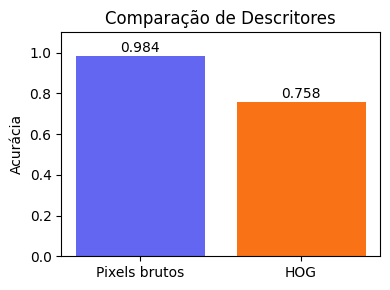

In [12]:
#| label: fig-07-comparativo-descritores
#| fig-cap: "Comparação de acurácia entre descritores de pixels brutos e HOG para o classificador k-NN (k=3) na base de dígitos."
#| echo: true
#| output: true

descritores_hog = np.array([
    hog(img, orientations=8, pixels_per_cell=(4, 4), cells_per_block=(1, 1))
    for img in digits.images
])
print(f"Dimensão do vetor HOG: {descritores_hog.shape[1]}")

Xh_treino, Xh_teste, yh_treino, yh_teste = train_test_split(
    descritores_hog, y, test_size=0.25, random_state=42, stratify=y
)

n_neighbors = 3
knn_hog = KNeighborsClassifier(n_neighbors=n_neighbors)
knn_hog.fit(Xh_treino, yh_treino)
pred_hog = knn_hog.predict(Xh_teste)
acc_hog = accuracy_score(yh_teste, pred_hog)
print(f"Acurácia (descritor HOG, k={n_neighbors}): {acc_hog:.4f}")

plt.figure(figsize=(4, 3))
plt.bar(["Pixels brutos", "HOG"], [acc_pixels, acc_hog], color=["#6366f1", "#f97316"])
plt.ylim(0, 1.1)  # Aumenta o limite superior para dar espaço
plt.ylabel("Acurácia")
plt.title("Comparação de Descritores")
for i, v in enumerate([acc_pixels, acc_hog]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")  # Aumenta o deslocamento vertical
plt.tight_layout()

:::{.callout-note}
## Por que funciona? — Nem sempre o descritor mais elaborado vence

Um resultado à primeira vista contraintuitivo é observado na @fig-07-comparativo-descritores:
os vetores de **intensidade bruta** superam o descritor **HOG** nesta base. A explicação
está no contexto dos dados: as imagens de `load_digits` já são pequenas
($8\times8$), pré-centralizadas e normalizadas — não há variação
significativa de iluminação, translação ou escala entre as amostras.
Nessas condições, a comparação pixel a pixel já é altamente informativa, e
a agregação promovida pelo HOG (histogramas por célula) descarta parte
dessa informação fina, que é justamente onde reside a diferença entre
dígitos visualmente semelhantes (como 4 e 9, ou 3 e 8).

O HOG tende a superar descritores de pixels brutos em cenários mais
realistas — imagens maiores, com variação de iluminação, pequenas
translações ou fundo não controlado — situações em que a estrutura local
de bordas é mais robusta do que a comparação direta de intensidades. Esse
resultado ilustra um princípio importante em reconhecimento de padrões:
**a escolha do descritor deve ser guiada pelas características do
problema**, não apenas pela sofisticação teórica do método.
:::

## Avaliação de Classificadores

A acurácia — proporção de acertos sobre o total de amostras — é uma
métrica intuitiva, mas insuficiente em problemas com classes
desbalanceadas. A **matriz de confusão** detalha os acertos e erros por
classe, permitindo calcular métricas complementares:

$$
\text{Precisão} = \frac{VP}{VP + FP}, \qquad
\text{Revocação} = \frac{VP}{VP + FN},
$$

em que $VP$, $FP$ e $FN$ denotam, respectivamente, o número de
verdadeiros positivos, falsos positivos e falsos negativos de uma classe
específica. A precisão mede a confiabilidade das predições positivas,
enquanto a revocação mede a capacidade do classificador de identificar
todos os exemplos verdadeiramente pertencentes à classe.

### Escolha de k por Validação Cruzada

O código a seguir avalia a acurácia média do classificador k-NN, por
validação cruzada de 5 partições (*5-fold cross-validation*), para
diferentes valores de $k$ na base de dígitos, permitindo identificar o
valor mais adequado. A @fig-07-elbow-k mostra os resultados obtidos.

Melhor valor de k encontrado: 2 (acurácia média=0.9672)


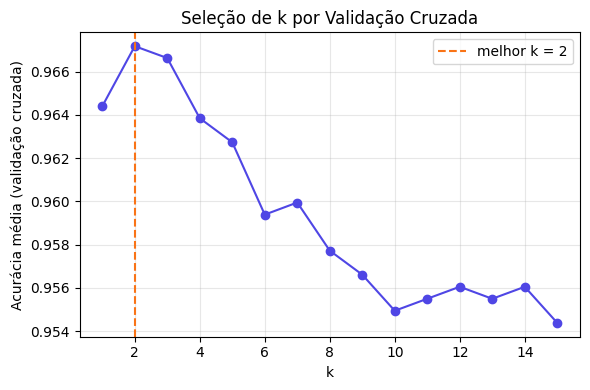

In [13]:
#| label: fig-07-elbow-k
#| fig-cap: "Acurácia média por validação cruzada (5 partições) em função do parâmetro k, para a base de dígitos com vetores de intensidade brutos."
#| echo: true
#| output: true

from sklearn.model_selection import cross_val_score

valores_k = range(1, 16)
acuracias_medias = []

for k in valores_k:
    modelo = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(modelo, X, y, cv=5)
    acuracias_medias.append(scores.mean())

melhor_k = list(valores_k)[int(np.argmax(acuracias_medias))]
print(f"Melhor valor de k encontrado: {melhor_k} (acurácia média={max(acuracias_medias):.4f})")

plt.figure(figsize=(6, 4))
plt.plot(list(valores_k), acuracias_medias, marker="o", color="#4f46e5")
plt.axvline(melhor_k, color="#f97316", linestyle="--", label=f"melhor k = {melhor_k}")
plt.xlabel("k")
plt.ylabel("Acurácia média (validação cruzada)")
plt.title("Seleção de k por Validação Cruzada")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

### O Compromisso entre Viés e Variância: Diagnóstico de Overfitting e Underfitting

A escolha do hiperparâmetro $k$ no classificador $k$-NN dita diretamente a complexidade geométrica da fronteira de decisão. Avaliar o desempenho do modelo exclusivamente sobre o conjunto de dados de treinamento é um erro metodológico clássico que mascara a incapacidade de generalização do algoritmo. Quando $k$ assume valores muito pequenos (como $k=1$), a fronteira de decisão molda-se perfeitamente aos ruídos e às peculiaridades das amostras de treino, atingindo uma acurácia próxima de 100% nesse conjunto, mas falhando severamente diante de dados inéditos — fenômeno conhecido como **sobreajuste** (*overfitting*). Por outro lado, se $k$ for excessivamente grande, o modelo perde sua sensibilidade local e passa a prever apenas a classe majoritária da região global, resultando em um **subajuste** (*underfitting*).

A **@fig-07-overfitting-analysis** ilustra o monitoramento sistemático dessas duas forças: ao contrastarmos as curvas de aprendizado do treino e do teste ao longo do espectro de vizinhos, torna-se possível delimitar a zona ideal de operação onde o modelo atinge o melhor compromisso entre viés e variância, maximizando a acurácia de teste.


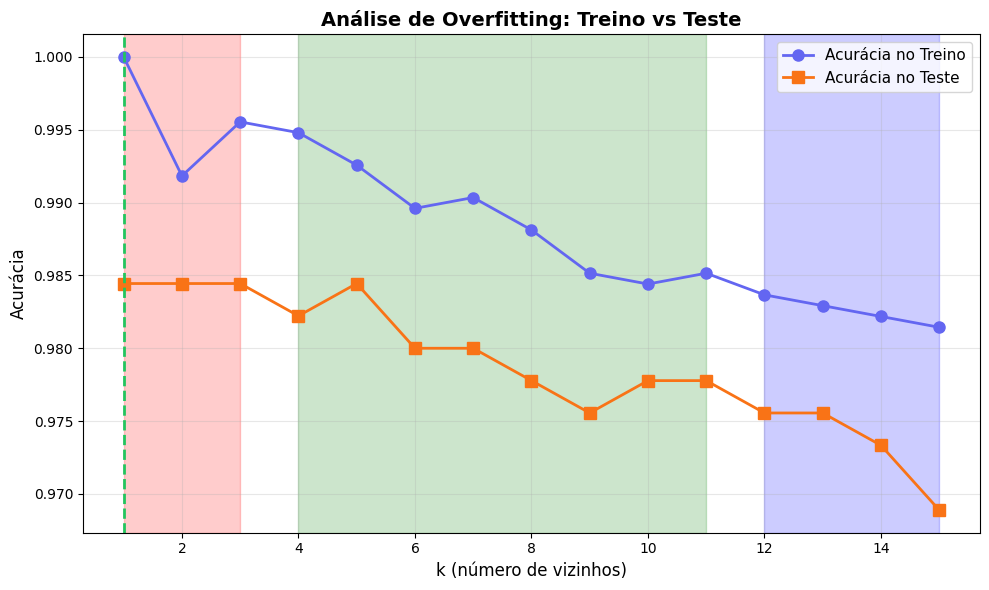


🔍 Análise de Overfitting:
   - k pequeno (1-3): alta acurácia no treino, baixa no teste → OVERFITTING
   - k médio (4-11): equilíbrio entre treino e teste → IDEAL
   - k grande (12-15): baixa acurácia em ambos → UNDERFITTING

✅ Melhor k para este problema: k=1


In [14]:
#| label: fig-07-overfitting-analysis
#| fig-cap: "Análise de overfitting: comparação da acurácia entre treino e teste para diferentes valores de k"
#| echo: true
#| output: true

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Análise de overfitting para diferentes k
k_values = range(1, 16)
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_treino, y_treino)
    
    train_acc = accuracy_score(y_treino, knn.predict(X_treino))
    test_acc = accuracy_score(y_teste, knn.predict(X_teste))
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Visualizar
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, 'o-', label='Acurácia no Treino', 
         color='#6366f1', linewidth=2, markersize=8)
plt.plot(k_values, test_scores, 's-', label='Acurácia no Teste', 
         color='#f97316', linewidth=2, markersize=8)
plt.xlabel('k (número de vizinhos)', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.title('Análise de Overfitting: Treino vs Teste', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

# Destacar regiões de overfitting e underfitting
plt.axvspan(1, 3, alpha=0.2, color='red', label='Overfitting (k pequeno)')
plt.axvspan(12, 15, alpha=0.2, color='blue', label='Underfitting (k grande)')
plt.axvspan(4, 11, alpha=0.2, color='green', label='Região ideal')

# Encontrar melhor k
melhor_k_teste = k_values[np.argmax(test_scores)]
plt.axvline(x=melhor_k_teste, color='#22c55e', linestyle='--', 
            label=f'melhor k (teste) = {melhor_k_teste}', linewidth=2)

plt.tight_layout()
plt.show()

print("\n🔍 Análise de Overfitting:")
print("   - k pequeno (1-3): alta acurácia no treino, baixa no teste → OVERFITTING")
print("   - k médio (4-11): equilíbrio entre treino e teste → IDEAL")
print("   - k grande (12-15): baixa acurácia em ambos → UNDERFITTING")
print(f"\n✅ Melhor k para este problema: k={melhor_k_teste}")

## Projeto Prático 2: Classificação de Texturas com Descritores LBP

No **Capítulo 6**, a variância local de textura foi utilizada para
**detectar** anomalias em superfícies industriais — uma tarefa binária de
"conforme" ou "defeituoso". Este projeto estende essa ideia para uma
tarefa de **classificação multi-classe**: dado um recorte de textura,
identificar a qual categoria ele pertence, utilizando o descritor LBP
combinado a um classificador k-NN.

Para garantir a reprodutibilidade do experimento sem depender de imagens
externas, três classes de textura são geradas sinteticamente: **granular**
(ruído gaussiano suavizado), **listrada** (padrão periódico) e **manchada**
(regiões circulares de intensidade variável). A @fig-07-texturas-amostra
mostra exemplos de cada classe.

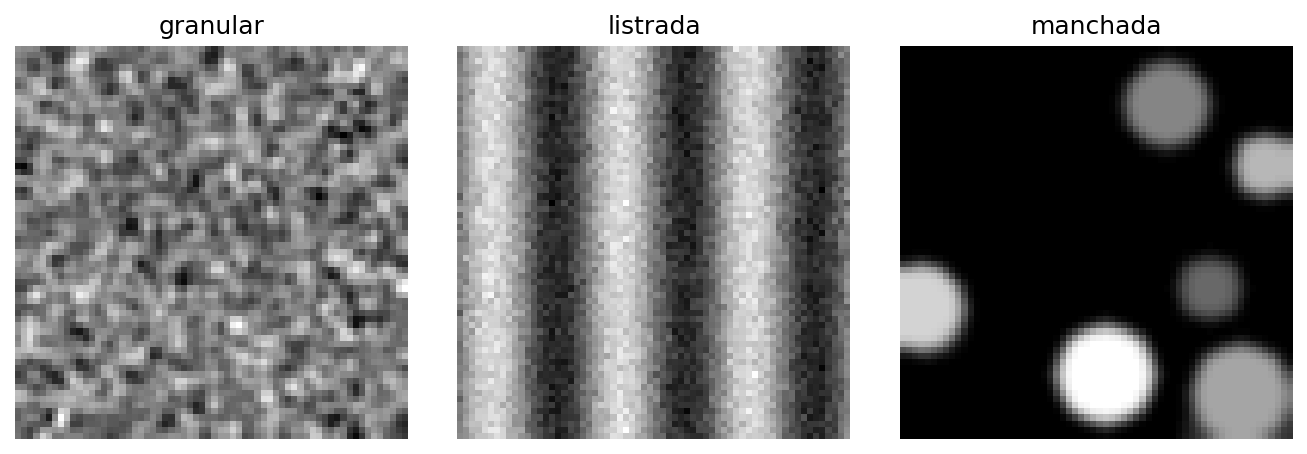

In [15]:
#| label: fig-07-texturas-amostra
#| fig-cap: "Amostras sintéticas das três classes de textura utilizadas no experimento de classificação."
#| echo: true
#| output: true

rng = np.random.default_rng(42)

def gerar_textura(classe, tamanho=64):
    # Gera uma textura sintética 64x64 para uma das classes: granular, listrada ou manchada.
    if classe == "granular":
        img = rng.normal(0.5, 0.18, (tamanho, tamanho))
        img = cv2.GaussianBlur(img.astype(np.float32), (3, 3), 0)
    elif classe == "listrada":
        eixo_x = np.linspace(0, 6 * np.pi, tamanho)
        base = 0.5 + 0.35 * np.sin(eixo_x)
        img = np.tile(base, (tamanho, 1)).astype(np.float32)
        img += rng.normal(0, 0.05, (tamanho, tamanho)).astype(np.float32)
    elif classe == "manchada":
        img = np.full((tamanho, tamanho), 0.5, dtype=np.float32)
        for _ in range(8):
            cx, cy = rng.integers(0, tamanho, 2)
            raio = int(rng.integers(4, 10))
            cv2.circle(img, (int(cx), int(cy)), raio, float(rng.uniform(0.2, 0.9)), -1)
        img = cv2.GaussianBlur(img, (5, 5), 0)
    else:
        raise ValueError(f"Classe desconhecida: {classe}")
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)

classes_textura = ["granular", "listrada", "manchada"]
amostras = [gerar_textura(c) for c in classes_textura]

mm.show(amostras, titles=classes_textura, cols=3, figsize=(9, 3))

### Extração do Descritor LBP e Treinamento do Classificador

Para cada textura, calcula-se o LBP uniforme e constrói-se um histograma
normalizado dos códigos obtidos — esse histograma é o vetor de
características utilizado pelo k-NN. A @fig-07-lbp-confusao mostra a
matriz de confusão do classificador treinado.

Acurácia (descritor LBP, k=5): 1.0000


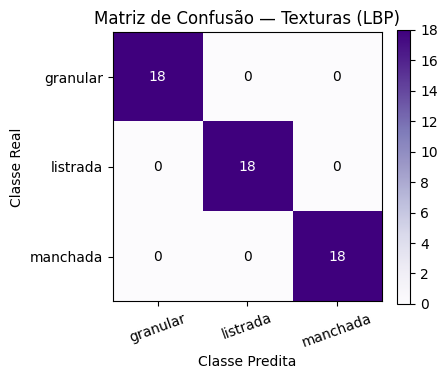

In [16]:
#| label: fig-07-lbp-confusao
#| fig-cap: "Matriz de confusão do classificador k-NN treinado com descritores LBP para as três classes de textura sintética."
#| echo: true
#| output: true

def descritor_lbp(img, P=8, R=1, bins=10):
    lbp = local_binary_pattern(img, P=P, R=R, method="uniform")
    hist, _ = np.histogram(lbp, bins=bins, range=(0, P + 2), density=True)
    return hist

X_textura, y_textura = [], []
for classe in classes_textura:
    for _ in range(60):
        img = gerar_textura(classe)
        X_textura.append(descritor_lbp(img))
        y_textura.append(classe)

X_textura = np.array(X_textura)
y_textura = np.array(y_textura)

Xt_treino, Xt_teste, yt_treino, yt_teste = train_test_split(
    X_textura, y_textura, test_size=0.3, random_state=0, stratify=y_textura
)

knn_textura = KNeighborsClassifier(n_neighbors=5)
knn_textura.fit(Xt_treino, yt_treino)
pred_textura = knn_textura.predict(Xt_teste)

acc_textura = accuracy_score(yt_teste, pred_textura)
print(f"Acurácia (descritor LBP, k=5): {acc_textura:.4f}")

cm_textura = confusion_matrix(yt_teste, pred_textura, labels=classes_textura)
plt.figure(figsize=(4.5, 4))
plt.imshow(cm_textura, cmap="Purples")
plt.xticks(range(3), classes_textura, rotation=20)
plt.yticks(range(3), classes_textura)
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.title("Matriz de Confusão — Texturas (LBP)")
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm_textura[i, j], ha="center", va="center",
                  color="white" if cm_textura[i, j] > cm_textura.max()/2 else "black")
plt.colorbar(fraction=0.046)
plt.tight_layout()

:::{.callout-note}
## Por que funciona? — LBP como assinatura de textura

O LBP resume, em um único histograma, a frequência de cada padrão local de
contraste presente na imagem. Texturas **granulares** produzem uma
distribuição de códigos aproximadamente uniforme, refletindo variações
aleatórias em todas as direções; texturas **listradas** concentram os
códigos em poucos padrões dominantes, associados às transições regulares
das faixas; texturas **manchadas** apresentam picos intermediários,
correspondentes às bordas suaves das regiões circulares.

Como o histograma descarta a informação espacial exata (apenas a
frequência dos padrões é preservada), o descritor é compacto e
relativamente robusto a pequenas translações e rotações da textura — a
mesma propriedade que, no Capítulo 6, permitiu à variância local
distinguir regiões "conformes" de regiões "defeituosas" em superfícies
industriais.
:::

### Diagnóstico Fino do Classificador: Precisão, Revocação e F1-Score

Embora a acurácia global forneça uma visão panorâmica do desempenho do sistema, ela pode ser uma métrica ilusória e perigosa em cenários práticos, mascarando falhas críticas em classes específicas ou ignorando o impacto de dados desbalanceados. Para uma auditoria rigorosa do pipeline de classificação, decompõe-se o comportamento do modelo em três dimensões complementares por classe: a **Precisão**, que avalia a confiabilidade das predições positivas (evitando falsos positivos); a **Revocação** (*Recall*), que mede a capacidade do algoritmo de mapear e resgatar todas as amostras reais pertencentes àquela categoria (evitando falsos negativos); e o **F1-Score**, que estabelece a média harmônica entre ambas.

A **@fig-07-metricas-avaliacao-detalhadas** apresenta a consolidação visual desse relatório analítico. Ao inspecionarmos o comportamento de cada descritor frente às diferentes categorias, torna-se imediato identificar assimetrias de comportamento — como classes que possuem alta precisão, mas baixa revocação —, fornecendo os insights de engenharia necessários para calibrar os limiares de decisão ou enriquecer o vetor de características do sistema.



=== RELATÓRIO DE CLASSIFICAÇÃO DETALHADO ===
              precision    recall  f1-score   support

    granular       1.00      1.00      1.00        18
    listrada       1.00      1.00      1.00        18
    manchada       1.00      1.00      1.00        18

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



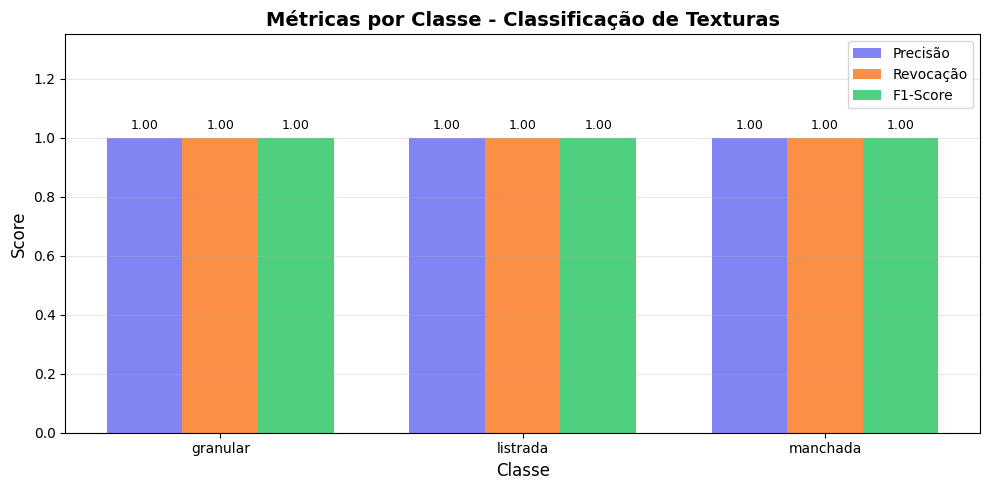


📊 Interpretação das métricas:
   - Precisão: Das predições positivas, quantas foram corretas?
   - Revocação: Dos exemplos positivos, quantos foram identificados?
   - F1-Score: Média harmônica entre precisão e revocação

💡 Em problemas desbalanceados, confie mais no F1-Score do que na acurácia!


In [17]:

#| label: fig-07-metricas-avaliacao-detalhadas
#| fig-cap: "Métricas de avaliação detalhadas para o classificador k-NN com descritores LBP"
#| echo: true
#| output: true

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Calcular métricas detalhadas
y_pred = knn_textura.predict(Xt_teste)

print("\n=== RELATÓRIO DE CLASSIFICAÇÃO DETALHADO ===")
print(classification_report(yt_teste, y_pred, target_names=classes_textura))

# Calcular métricas por classe
precision = precision_score(yt_teste, y_pred, average=None, labels=classes_textura)
recall = recall_score(yt_teste, y_pred, average=None, labels=classes_textura)
f1 = f1_score(yt_teste, y_pred, average=None, labels=classes_textura)

# Criar visualização das métricas
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(classes_textura))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precisão', color='#6366f1', alpha=0.8)
bars2 = ax.bar(x, recall, width, label='Revocação', color='#f97316', alpha=0.8)
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#22c55e', alpha=0.8)

ax.set_xlabel('Classe', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Métricas por Classe - Classificação de Texturas', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes_textura)
ax.legend(loc='upper right')
ax.set_ylim(0, 1.35)
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 Interpretação das métricas:")
print("   - Precisão: Das predições positivas, quantas foram corretas?")
print("   - Revocação: Dos exemplos positivos, quantos foram identificados?")
print("   - F1-Score: Média harmônica entre precisão e revocação")
print("\n💡 Em problemas desbalanceados, confie mais no F1-Score do que na acurácia!")

## Limitações dos Descritores Artesanais

Os experimentos deste capítulo evidenciam tanto o valor quanto as
limitações dos descritores clássicos:

* **Especificidade:** um descritor projetado para capturar textura (LBP)
  ou forma (HOG) pode ser inadequado para outras propriedades relevantes
  da imagem — não existe um único descritor artesanal universalmente
  eficaz;
* **Sensibilidade a hiperparâmetros:** o desempenho de descritores como o
  HOG depende fortemente de escolhas como o tamanho da célula, o número de
  orientações e o tamanho do bloco — parâmetros que precisam ser ajustados
  manualmente para cada domínio de aplicação;
* **Dificuldade em capturar semântica de alto nível:** descritores de cor,
  textura e gradiente descrevem propriedades locais e de baixo nível da
  imagem, mas não capturam diretamente conceitos semânticos complexos
  (por exemplo, "há um rosto humano nesta imagem, independentemente de
  pose, iluminação ou oclusão");
* **Maldição da dimensionalidade:** conforme discutido, descritores muito
  extensos degradam a eficácia de classificadores baseados em distância,
  como o k-NN.

Essas limitações motivam os próximos capítulos desta parte, que empregam
descritores igualmente artesanais para tarefas específicas (Haar Cascade
para detecção de faces, no Capítulo 8) e, ao final, apresentam as **Redes
Neurais Convolucionais** (Capítulo 12), capazes de **aprender**
automaticamente, a partir dos dados, os descritores mais adequados a cada
tarefa — superando muitas das limitações discutidas aqui.



## Resumo

Neste capítulo foram apresentados os fundamentos do reconhecimento de
padrões aplicado a imagens.

* **Pipeline de reconhecimento de padrões:** aquisição, pré-processamento,
  extração de descritores, classificação e avaliação constituem o
  fluxo padrão de qualquer sistema de classificação de imagens;
* **Descritores clássicos:** o LBP captura padrões locais de textura por
  meio da comparação entre um pixel e sua vizinhança circular; o HOG
  captura a forma de um objeto pela distribuição de orientações do
  gradiente;
* **Classificador k-NN:** classifica uma nova observação pela votação
  majoritária de seus $k$ vizinhos mais próximos no espaço de
  características, sem exigir uma fase de treinamento explícita além do
  armazenamento dos exemplos;
* **Efeito do parâmetro k:** valores pequenos geram fronteiras irregulares
  (alta variância); valores grandes geram fronteiras suaves (alto viés).
  O valor ideal é tipicamente escolhido por validação cruzada;
* **Avaliação de classificadores:** acurácia, matriz de confusão,
  precisão e revocação oferecem visões complementares sobre a qualidade
  de um classificador;
* **Limitações dos descritores artesanais:** especificidade, dependência
  de hiperparâmetros e dificuldade em capturar semântica de alto nível
  motivam a evolução, nos próximos capítulos, rumo a descritores
  aprendidos automaticamente por redes neurais profundas.

## 🤖 Uso do NotebookLM como Tutor Complementar

Nesta edição, o uso do **NotebookLM** é incentivado como ferramenta
complementar de aprendizagem. Baseado em inteligência artificial, o sistema
utiliza exclusivamente os documentos fornecidos pelo autor como fonte de
conhecimento, produzindo respostas alinhadas ao conteúdo e à abordagem
adotada ao longo deste capítulo.

:::{.callout-important appearance="default" icon=false}

### 🎓 Estude com o Tutor Inteligente {.unnumbered}

[🚀 ACESSAR NOTEBOOKLM: CAPÍTULO 07](https://notebooklm.google.com/)

#### ⚠️ Aviso sobre Conteúdo Gerado por IA {.unnumbered}

Embora seja uma ferramenta valiosa de apoio aos estudos, o NotebookLM pode
eventualmente produzir respostas incompletas, imprecisas ou incorretas.
Recomenda-se validar as informações consultando o material do capítulo,
livros, artigos científicos e outras fontes acadêmicas confiáveis. Sempre
que possível, execute e experimente os exemplos práticos apresentados ao
longo do texto para consolidar a compreensão dos conceitos.
:::

## Lista de Exercícios

Os exercícios a seguir consolidam os fundamentos teóricos do capítulo.
Cada questão tem um peso (0-10) indicando sua importância relativa.

### Exercício Conceitual 1: Entendendo Descritores (Peso 1)

**Questão:** Explique, em suas próprias palavras, por que descritores como LBP e HOG são
considerados "invariantes" a certas transformações. Dê um exemplo de uma
transformação que cada um tolera e explique o mecanismo que proporciona
essa invariância.

**Solução esperada (resumo):**
- LBP: Invariante a variações monotônicas de iluminação porque usa comparações
  relativas (maior/menor) em vez de valores absolutos
- HOG: Parcialmente invariante a pequenas translações porque agrega gradientes
  em células
- Exemplo prático: Uma imagem mais escura vs mais clara

### Exercício Conceitual 2: Escolhendo o Descritor Certo (Peso 2)

**Questão:** Você precisa classificar imagens de dois conjuntos de dados:
1. **Conjunto A:** Peças metálicas com diferentes tipos de textura superficial
   (lisa, rugosa, estriada) sob iluminação controlada
2. **Conjunto B:** Silhuetas de animais em fotografias ao ar livre

Para cada conjunto, indique qual descritor (pixels brutos, LBP ou HOG) você
escolheria e justifique sua escolha considerando:
- As características distintivas de cada classe
- As variações esperadas nas imagens
- As limitações de cada descritor para o problema específico

**Solução esperada:**
- Conjunto A: LBP (textura é a principal diferença)
- Conjunto B: HOG (forma e contorno são mais importantes que textura)

### Exercício Conceitual 3: O Dilema do k (Peso 2)

**Questão:** Um classificador k-NN foi treinado com dois valores diferentes de k:

| k | Acurácia Treino | Acurácia Teste |
|---|----------------|----------------|
| 1 | 98%            | 72%            |
| 15| 84%            | 83%            |

1. Qual configuração apresenta indícios de **overfitting**? Explique.
2. Qual você escolheria para produção e por quê?
3. Que valor de k você tentaria a seguir e por quê?

**Solução esperada:**
1. k=1 mostra overfitting (treino muito alto, teste muito baixo)
2. k=15 é mais confiável (desempenho consistente)
3. Testaríamos valores entre 5-10 para buscar melhor compromisso

### Exercício Conceitual 4: A Maldição da Dimensionalidade (Peso 2)

**Questão:** Considere duas abordagens para classificar dígitos manuscritos:

- **Abordagem A:** Imagens 8x8 = 64 pixels como features
- **Abordagem B:** Imagens 32x32 = 1024 pixels como features

1. Qual abordagem seria mais afetada pela "maldição da dimensionalidade"? Por quê?
2. Como você poderia mitigar esse problema na abordagem B?
3. Por que descritores como HOG podem ajudar nesse cenário?

**Solução esperada:**
1. Abordagem B (mais dimensões)
2. Redução de dimensionalidade (PCA), seleção de features
3. HOG reduz dimensionalidade enquanto preserva informações relevantes

### Exercício Conceitual 5: Projetando um Sistema de Classificação (Peso 3)

**Questão:** Você precisa classificar automóveis em uma estrada de pedágio
em três categorias: **Carro**, **Caminhão** e **Motocicleta**, baseado
em imagens capturadas de cima.

Projete um sistema completo de classificação considerando:
1. **Pré-processamento:** Que transformações seriam necessárias?
2. **Descritores:** Que descritores você usaria e por quê?
3. **Classificador:** Por que escolheria k-NN ou outro método?
4. **Avaliação:** Como validaria seu sistema?
5. **Desafios:** Quais dificuldades práticas você antecipa?

**Solução esperada:**
- Pré-processamento: Normalização de escala (carros de diferentes tamanhos)
- Descritores: HOG para forma, complementado com medidas de proporção
- Classificador: k-NN para simplicidade inicial, validação cruzada para escolher k
- Avaliação: Matriz de confusão para ver erros entre classes similares
- Desafios: Motos podem ser confundidas com carros em alguns ângulos

## Próximos Passos

Neste capítulo foi apresentado o pipeline clássico de reconhecimento de
padrões — da extração de descritores de cor, textura (LBP) e forma
(HOG) à classificação por k-NN e à avaliação sistemática de
classificadores. Esses conceitos formam a base conceitual sobre a qual se
apoiam praticamente todas as tarefas subsequentes de Visão Computacional.

O **Capítulo 8** aplica esses fundamentos a um problema clássico e de
grande impacto prático: a **detecção de objetos**. Partindo do algoritmo
de **Haar Cascade** (Viola-Jones), amplamente utilizado em detecção de
faces e olhos, o capítulo discute como um classificador binário (objeto
presente ou ausente) pode ser combinado a uma janela deslizante
(*sliding window*) em múltiplas escalas para localizar objetos em
posições arbitrárias de uma imagem — e como essa ideia evoluiu para as
famílias modernas de detectores baseados em *bounding boxes*.